### Sketch
Sketch is an AI code-writing assistant for pandas users that understands the context of your data, greatly improving the relevance of suggestions. Sketch is usable in seconds and doesn't require adding a plugin to your IDE.
### Sources:
* https://github.com/approximatelabs/sketch
* https://towardsdatascience.com/sketch-a-promising-ai-library-to-help-with-pandas-dataframes-directly-in-jupyter-5162c32c66ef
* https://www.youtube.com/watch?v=sFEyZv0o1bo

In [1]:
#!pip install sketch

In [9]:
import pandas as pd
import sketch

In [11]:
df = pd.read_csv("data/Demographic-NY.csv")
df

,JURISDICTION NAME,COUNT PARTICIPANTS,COUNT FEMALE,PERCENT FEMALE,COUNT MALE,PERCENT MALE,COUNT GENDER UNKNOWN,PERCENT GENDER UNKNOWN,COUNT GENDER TOTAL,PERCENT GENDER TOTAL,...,COUNT CITIZEN STATUS TOTAL,PERCENT CITIZEN STATUS TOTAL,COUNT RECEIVES PUBLIC ASSISTANCE,PERCENT RECEIVES PUBLIC ASSISTANCE,COUNT NRECEIVES PUBLIC ASSISTANCE,PERCENT NRECEIVES PUBLIC ASSISTANCE,COUNT PUBLIC ASSISTANCE UNKNOWN,PERCENT PUBLIC ASSISTANCE UNKNOWN,COUNT PUBLIC ASSISTANCE TOTAL,PERCENT PUBLIC ASSISTANCE TOTAL
0,10001,44,22,0.50,22,0.50,0,0,44,100,...,44,100,20,0.45,24,0.55,0,0,44,100
1,10002,35,19,0.54,16,0.46,0,0,35,100,...,35,100,2,0.06,33,0.94,0,0,35,100
2,10003,1,1,1.00,0,0.00,0,0,1,100,...,1,100,0,0.00,1,1.00,0,0,1,100
3,10004,0,0,0.00,0,0.00,0,0,0,0,...,0,0,0,0.00,0,0.00,0,0,0,0
4,10005,2,2,1.00,0,0.00,0,0,2,100,...,2,100,0,0.00,2,1.00,0,0,2,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,12788,83,39,0.47,44,0.53,0,0,83,100,...,83,100,35,0.42,48,0.58,0,0,83,100
232,12789,272,115,0.42,157,0.58,0,0,272,100,...,272,100,70,0.26,202,0.74,0,0,272,100
233,13731,17,2,0.12,15,0.88,0,0,17,100,...,17,100,7,0.41,10,0.59,0,0,17,100
234,16091,0,0,0.00,0,0.00,0,0,0,0,...,0,0,0,0.00,0,0.00,0,0,0,0


In [12]:
# Sketch can handle only 20 columns, so I'm dropping out some here
df=df[['JURISDICTION NAME', 'COUNT PARTICIPANTS', 'COUNT FEMALE',
        'COUNT MALE', 
        'COUNT GENDER TOTAL', 
       'COUNT PACIFIC ISLANDER', 
       'COUNT HISPANIC LATINO', 
       'COUNT AMERICAN INDIAN', 
       'COUNT ASIAN NON HISPANIC', 
       'COUNT WHITE NON HISPANIC', 
       'COUNT BLACK NON HISPANIC',
       'COUNT OTHER ETHNICITY',
       'COUNT ETHNICITY TOTAL', 
       'COUNT PERMANENT RESIDENT ALIEN', 
       'COUNT US CITIZEN', 'COUNT OTHER CITIZEN STATUS',
        'COUNT CITIZEN STATUS TOTAL',
       'COUNT RECEIVES PUBLIC ASSISTANCE',              
       'COUNT PUBLIC ASSISTANCE TOTAL' ]]

In [13]:
df.sketch.ask("What is this dataset about?")

In [15]:
outp = df.sketch.ask("Plot the count of genders in each jurisdiction?", call_display=False)

In [16]:
outp

'\nTo plot the count of genders in each jurisdiction, you can use the `groupby` function to group the data by jurisdiction and then use the `count` function to count the number of rows for each gender. Then, you can use the `plot` function to create a bar chart showing the count of genders for each jurisdiction.\n\nExample code:\n\n'

In [17]:
outp = df.sketch.howto("Plot the count of genders in each jurisdiction?", call_display=False)

In [ ]:
import matplotlib.pyplot as plt 
# Get the data for plotting 
jurisdiction_names = df['JURISDICTION NAME'].unique() 
count_female = df.groupby('JURISDICTION NAME')['COUNT FEMALE'].sum() 
count_male = df.groupby('JURISDICTION NAME')['COUNT MALE'].sum() 
# Create the plot plt.bar(jurisdiction_names, count_female, label='Female') 
plt.bar(jurisdiction_names, count_male, bottom=count_female, label='Male') 
plt.xlabel('Jurisdiction Name') plt.ylabel('Count of Genders') 
plt.title('Count of Genders in Each Jurisdiction') plt.legend() 
plt.show() 

In [10]:
outp = df.sketch.howto("Plot the count of each gender in each jurisdiction.")

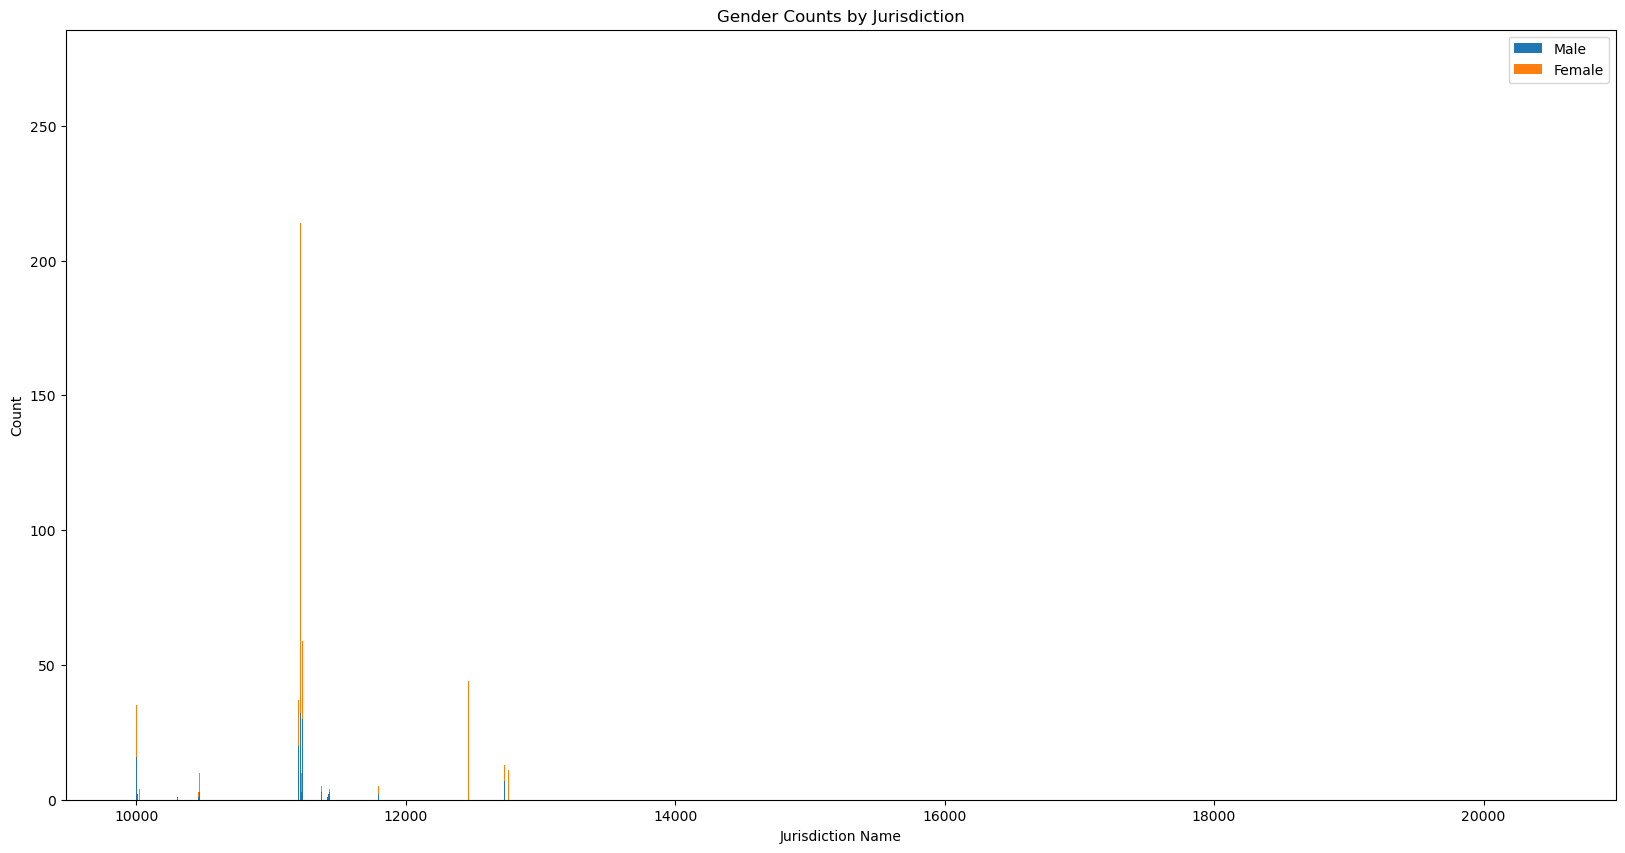

In [20]:
import matplotlib.pyplot as plt

# Get the data for plotting
jurisdiction_names = df['JURISDICTION NAME'].unique()
male_counts = df.groupby('JURISDICTION NAME')['COUNT MALE'].sum()
female_counts = df.groupby('JURISDICTION NAME')['COUNT FEMALE'].sum()

# Create the plot
fig, ax = plt.subplots(figsize=(20,10))
#plt.figure(figsize=(20,10)) # Set the figure size to be as wide as the page width
ax.bar(jurisdiction_names, male_counts, label='Male')
ax.bar(jurisdiction_names, female_counts, bottom=male_counts, label='Female')
ax.set_title('Gender Counts by Jurisdiction')
ax.set_xlabel('Jurisdiction Name')
ax.set_ylabel('Count')
ax.legend()
plt.show()



In [21]:
 df.sketch.ask("Is there a difference between ethnicities receiving assistance?")

<AxesSubplot:xlabel='JURISDICTION NAME'>

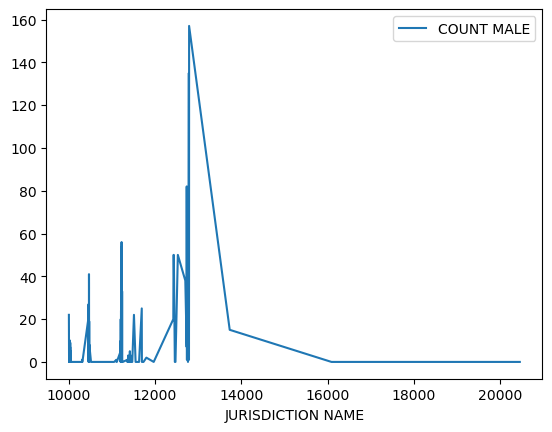

In [16]:
df.plot('JURISDICTION NAME', 'COUNT MALE')

In [18]:
df.sketch.howto("Given this python code 'import matplotlib.pyplot as plt # Get the data for plotting jurisdiction_names = df['JURISDICTION NAME'].unique() count_female = df.groupby('JURISDICTION NAME')['COUNT FEMALE'].sum() count_male = df.groupby('JURISDICTION NAME')['COUNT MALE'].sum() # Create the plot plt.bar(jurisdiction_names, count_female, label='Female') plt.bar(jurisdiction_names, count_male, bottom=count_female, label='Male') plt.xlabel('Jurisdiction Name') plt.ylabel('Count of Genders') plt.title('Count of Genders in Each Jurisdiction') plt.legend() plt.show()' make this plot as wide as the page width ")

In [15]:
df.sketch.ask("In which country do they give this kind of labels to jurisdictions?")

### Traffic Violations

In [5]:
tdf = pd.read_csv("data/traffic-violation-small.csv")
tdf.head()

,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,Belts,...,Charge,Article,Contributed To Accident,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation
0,09/24/2013,17:11:00,MCP,"3rd district, Silver Spring",DRIVING VEHICLE ON HIGHWAY WITH SUSPENDED REGI...,8804 FLOWER AVE,NaN,NaN,No,No,...,13-401(h),Transportation Article,No,BLACK,M,TAKOMA PARK,MD,MD,A - Marked Patrol,NaN
1,08/29/2017,10:19:00,MCP,"2nd district, Bethesda",DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC...,WISCONSIN AVE@ ELM ST,38.981725,-77.092757,No,No,...,21-201(a1),Transportation Article,No,WHITE,F,FAIRFAX STATION,VA,VA,A - Marked Patrol,"(38.981725, -77.0927566666667)"
2,12/01/2014,12:52:00,MCP,"6th district, Gaithersburg / Montgomery Village",FAILURE STOP AND YIELD AT THRU HWY,CHRISTOPHER AVE/MONTGOMERY VILLAGE AVE,39.162888,-77.229088,No,No,...,21-403(b),Transportation Article,No,BLACK,F,UPPER MARLBORO,MD,MD,A - Marked Patrol,"(39.1628883333333, -77.2290883333333)"
3,08/29/2017,09:22:00,MCP,"3rd district, Silver Spring",FAILURE YIELD RIGHT OF WAY ON U TURN,CHERRY HILL RD./CALVERTON BLVD.,39.056975,-76.954633,No,No,...,21-402(b),Transportation Article,No,BLACK,M,FORT WASHINGTON,MD,MD,A - Marked Patrol,"(39.056975, -76.9546333333333)"
4,08/28/2017,23:41:00,MCP,"6th district, Gaithersburg / Montgomery Village",FAILURE OF DR. TO MAKE LANE CHANGE TO AVAIL. L...,355 @ SOUTH WESTLAND DRIVE,NaN,NaN,No,No,...,21-405(e1),Transportation Article,No,WHITE,M,GAITHERSBURG,MD,MD,A - Marked Patrol,NaN


In [6]:
tdf.sketch

In [7]:
%env SKETCH_MAX_COLUMNS=40

env: SKETCH_MAX_COLUMNS=40


In [8]:
tdf.sketch.ask("Can you describe this dataset for me?")

In [10]:
tdf.columns

Index(['Date Of Stop', 'Time Of Stop', 'Agency', 'SubAgency', 'Description',
       'Location', 'Latitude', 'Longitude', 'Accident', 'Belts',
       'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License',
       'HAZMAT', 'Commercial Vehicle', 'Alcohol', 'Work Zone', 'State',
       'VehicleType', 'Year', 'Make', 'Model', 'Color', 'Violation Type',
       'Charge', 'Article', 'Contributed To Accident', 'Race', 'Gender',
       'Driver City', 'Driver State', 'DL State', 'Arrest Type',
       'Geolocation'],
      dtype='object')

In [11]:
ttdf = tdf[['Date Of Stop', 'Time Of Stop', 'Description',
       'Location', 'Latitude', 'Longitude', 'Accident', 'Belts',
       'Personal Injury', 
       'HAZMAT', 'Alcohol', 'Work Zone', 'State',
       'VehicleType', 'Year', 'Make', 'Model', 'Color', 'Violation Type',
       'Charge', 'Article', 'Contributed To Accident', 'Race', 'Gender',       
       'Geolocation']]

In [13]:
ttdf.sketch.howto("Which areas are the most prone to any traffic stops. Using plotly, create a density plot of the locations, where any violation happened with 1 km resolution. z value sould be omitted")

In [15]:


#import necessary libraries
import plotly.express as px

#create a new column with the geolocation coordinates in a tuple format
ttdf['Geolocation_tuple'] = ttdf['Geolocation'].apply(lambda x: tuple(map(float, x.strip('()').split(','))) if isinstance(x, str) else None)

#create a density plot of the locations, where any violation happened with 1 km resolution
fig = px.density_mapbox(ttdf, lat='Latitude', lon='Longitude', radius=1,
                        center=dict(lat=39.0, lon=-77.0), zoom=9,
                        mapbox_style="stamen-terrain")
fig.show()


/tmp/ipykernel_513/2897873965.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

